In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve

data = pd.read_excel('/content/dataset.xlsx')
features_df = pd.read_csv('/content/FINAL_35_features_selected.csv')
FINAL_FEATURES = features_df['feature'].tolist()

X = data[FINAL_FEATURES]
y = data['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_proba = rf_model.predict_proba(X_test)[:, 1]
y_true  = y_test.values

fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
YOUDEN_THRESH = thresholds_roc[np.argmax(tpr - fpr)]
print(f"Model: Random Forest Default")
print(f"Youden threshold: {YOUDEN_THRESH:.4f}")
print(f"Train={len(X_train)}, Test={len(X_test)}")


Model: Random Forest Default
Youden threshold: 0.5311
Train=708, Test=178


**DCA RANDOM FOREST**

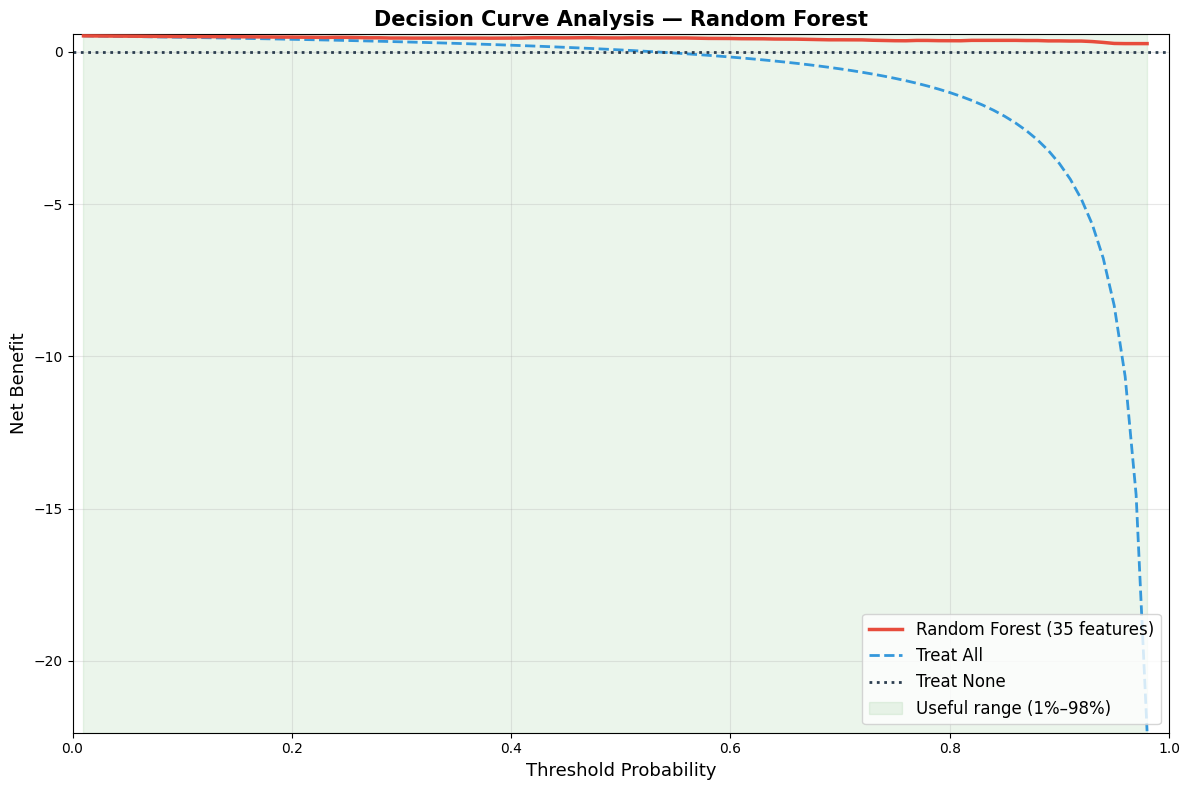

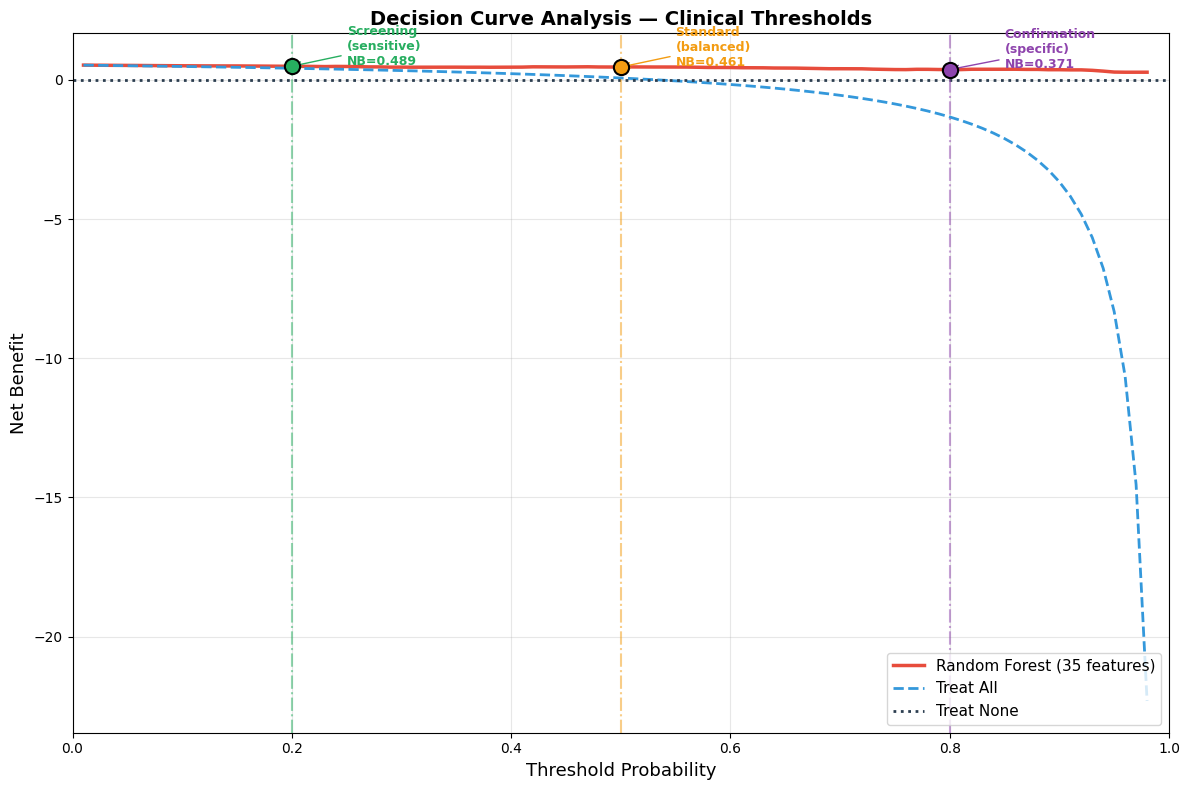


  test: 53.4%
   Zona utila model: 1% – 98%

   Net Benefit la praguri clinice:
     Threshold 20% (Screening (sensitive)):  NB=0.4888  (vs Treat All: 0.4171, Improvement: +0.0716)
     Threshold 50% (Standard (balanced)):  NB=0.4607  (vs Treat All: 0.0674, Improvement: +0.3933)
     Threshold 80% (Confirmation (specific)):  NB=0.3708  (vs Treat All: -1.3315, Improvement: +0.3708)

   Figuri salvate


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def decision_curve_analysis(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.01, 0.99, 0.01)
    n = len(y_true)
    prevalence = y_true.mean()
    nb_model, nb_treat_all = [], []
    for pt in thresholds:
        y_pred = (y_proba >= pt).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        nb_model.append((tp/n) - (fp/n) * (pt/(1-pt)))
        nb_treat_all.append(prevalence - (1-prevalence) * (pt/(1-pt)))
    return thresholds, np.array(nb_model), np.array(nb_treat_all)

thresholds, nb_model, nb_treat_all = decision_curve_analysis(y_true, y_proba)

useful_range = thresholds[(nb_model > 0) & (nb_model > nb_treat_all)]
useful_min = useful_range[0] if len(useful_range) > 0 else 0
useful_max = useful_range[-1] if len(useful_range) > 0 else 0


fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(thresholds, nb_model, color='#e74c3c', linewidth=2.5,
        label='Random Forest (35 features)', zorder=3)
ax.plot(thresholds, nb_treat_all, color='#3498db', linewidth=2,
        linestyle='--', label='Treat All', zorder=2)
ax.axhline(y=0, color='#2c3e50', linewidth=2, linestyle=':',
           label='Treat None', zorder=2)
if len(useful_range) > 0:
    ax.axvspan(useful_min, useful_max, alpha=0.08, color='green',
               label=f'Useful range ({useful_min:.0%}–{useful_max:.0%})')
ax.set_xlabel('Threshold Probability', fontsize=13)
ax.set_ylabel('Net Benefit', fontsize=13)
ax.set_title('Decision Curve Analysis — Random Forest', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([min(nb_model.min(), nb_treat_all.min()) - 0.05,
             max(nb_model.max(), nb_treat_all.max()) + 0.05])
plt.tight_layout()
plt.savefig('DCA_decision_curve.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(thresholds, nb_model, color='#e74c3c', linewidth=2.5,
        label='Random Forest (35 features)')
ax.plot(thresholds, nb_treat_all, color='#3498db', linewidth=2,
        linestyle='--', label='Treat All')
ax.axhline(y=0, color='#2c3e50', linewidth=2, linestyle=':',
           label='Treat None')

clinical_thresholds = {
    0.20: ('Screening\n(sensitive)', '#27ae60'),
    0.50: ('Standard\n(balanced)', '#f39c12'),
    0.80: ('Confirmation\n(specific)', '#8e44ad'),
}
for pt, (label, color) in clinical_thresholds.items():
    idx = int(pt * 100) - 1
    if 0 <= idx < len(nb_model):
        ax.axvline(x=pt, color=color, linestyle='-.', alpha=0.5, linewidth=1.5)
        ax.scatter([pt], [nb_model[idx]], color=color, s=120, zorder=5,
                   edgecolor='black', linewidth=1.5)
        ax.annotate(f'{label}\nNB={nb_model[idx]:.3f}',
                    xy=(pt, nb_model[idx]),
                    xytext=(pt + 0.05, nb_model[idx] + 0.04),
                    fontsize=9, fontweight='bold', color=color,
                    arrowprops=dict(arrowstyle='->', color=color))

ax.set_xlabel('Threshold Probability', fontsize=13)
ax.set_ylabel('Net Benefit', fontsize=13)
ax.set_title('Decision Curve Analysis — Clinical Thresholds', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
plt.tight_layout()
plt.savefig('DCA_clinical_thresholds.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n  test: {y_true.mean():.1%}")
print(f"   Zona utila model: {useful_min:.0%} – {useful_max:.0%}")
print(f"\n   Net Benefit la praguri clinice:")
for pt, (label, _) in clinical_thresholds.items():
    idx = int(pt * 100) - 1
    if 0 <= idx < len(nb_model):
        nb_all_val = nb_treat_all[idx]
        nb_mod_val = nb_model[idx]
        improvement = nb_mod_val - max(nb_all_val, 0)
        print(f"     Threshold {pt:.0%} ({label.replace(chr(10), ' ')}):  "
              f"NB={nb_mod_val:.4f}  "
              f"(vs Treat All: {nb_all_val:.4f}, "
              f"Improvement: +{improvement:.4f})")
print(f"\n   Figuri salvate")